# Flexibility

How much of the fleet's home charging could move, half-hour by half-hour: how much the
*unmanaged* fleet could turn down (deferrable power) and how much headroom the *smart* fleet
still has to turn up. Every figure here is a spread across simulated weeks, never a single
number, because the model aggregates world-first (decision 0004 item 12, contract v2 rule 3):
each simulated week's own value is computed first, and only then is a spread taken across weeks.

**The idea in one paragraph.** At any half-hour, some plugged-in EVs are still below their
preferred target. Together their home chargers could draw `flexible_power_kw` (decision 0004
item 43) if every one of them charged flat out right now — but not every EV needs to charge
*now*: each has **slack**, the hours between now and its expected departure once the whole
half-hours it still needs at full power are subtracted. `deferrable_power_bands` splits that
ceiling by slack bucket, on the *unmanaged* path (the counterfactual Axle would be moving
charging away from). The *smart* path already waits for the cheapest half-hours, so at most other
times it draws less than its own ceiling: that unused ceiling is **turn-up headroom**
(`turn_up_headroom_kw`) — headroom sitting unused while the plan waits, not extra flexibility the
fleet does not otherwise have.

The notebook calls the same functions the app does (`forecast.run_forecast_from_assumptions`,
reading `deferrable_power_bands`, `flexibility_weekly_summary` and `flexibility_bands` straight
off the result) and reads every quoted default from `model/assumptions.py`.

**Sections**

1. Deferrable power by slack, and time slack
2. Each week's own peak: why the total is a band, not a number
3. Turn-up headroom on the smart path
4. A pointer to firm MW (`model/availability.py`)
5. Sanity checks
6. Limitations

In [1]:
# --- MODEL IMPORTS (one cell) -----------------------------------------------
from datetime import date

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

from axle_studio.model import assumptions, availability
from axle_studio.model.forecast import run_forecast_from_assumptions
from axle_studio.model.summaries import AT_LEAST_HOURS, DEFERRABLE_BUCKET_ORDER, SLACK_BUCKETS
from axle_studio.ui.style import (
    PATH_LABELS,
    PATH_STYLES,
    SEQUENTIAL,
    apply_notebook_style,
    band_and_line,
)

# "notebook_connected" embeds only the figure data and loads plotly.js from a CDN, which keeps the
# committed notebook small. GitHub does not run that script, so every chart has a table under it.
pio.renderers.default = "notebook_connected"
pd.set_option("display.width", 120)
LONDON = "Europe/London"

## Try it

The run is small so the notebook stays fast (a few seconds); raise `VEHICLE_COUNT` and
`WORLD_COUNT` for steadier bands. Both paths share the same expected-departure rule (the smart
charger's own departure margin, decision 0004 item 51), so the two paths' flexibility is compared
on equal terms.

In [2]:
START_LOCAL_DATE = date(2026, 1, 12)  # the London date the seven study nights start (a Monday)
VEHICLE_COUNT = 50
WORLD_COUNT = 20  # simulated weeks
EXAMPLE_NIGHT = 0  # the session night the "one evening" tables below read

base = run_forecast_from_assumptions(
    START_LOCAL_DATE,
    values={"vehicle_count": VEHICLE_COUNT, "evaluation_world_count": WORLD_COUNT},
)
night_slots = base.study_slots.query("night_index == @EXAMPLE_NIGHT")[
    ["slot_index", "local_time_label"]
]
pd.DataFrame(
    [
        {
            "policy_id": base.policy_id,
            "evidence_kind": base.evidence_kind,
            "vehicles": base.vehicle_count,
            "simulated weeks": base.world_count,
            "fleet charger capacity kW": base.flexibility_weekly_summary.at[
                0, "fleet_charger_capacity_kw"
            ],
        }
    ]
)

,policy_id,evidence_kind,vehicles,simulated weeks,fleet charger capacity kW
0,explicit_synthetic_wholesale_v1,illustrative_synthetic,50,20,350.0


## 1. Deferrable power by slack, and time slack

`deferrable_power_bands` (contract v2 3.6d) splits the unmanaged path's flexible ceiling by
**slack**: for each plugged-in, below-target EV, its hours to expected departure minus the whole
half-hours it still needs at full power (`summaries.SLACK_BUCKETS`; a need of 0.2 h still holds
one half-hour, because the kernel dispatches in whole slots, decision 0001). An EV with negative
slack cannot reach its target in time even charging flat out from now — it sits in the `under_1h`
"must run now" bucket alongside anything genuinely under an hour of slack.

The five buckets are disjoint and add up to the total *inside every simulated week*. The
cumulative "at least N hours" rows below them are **nested subsets** of each other instead (every
EV that can wait 2 h or more can also wait 1 h or more), so their per-slot medians can never
cross: taking a subset of a world's own values can only lower or hold its median, never raise it,
so median("at least 2 h") <= median("at least 1 h") at every half-hour. That is why the chart
below can be read like a stack of nested areas without ever adding two quantiles together — the
one thing a quantile frame must never do (results contract v2 rule 3).

`time_slack_hours` is the same underlying slack, per plugged-in EV below target, with **two**
spreads (decision 0004 item 40): across EVs within one week (how unevenly slack is spread on one
night) and across weeks (how that typical EV's own slack moves week to week). Both are shown so
neither is mistaken for the other.

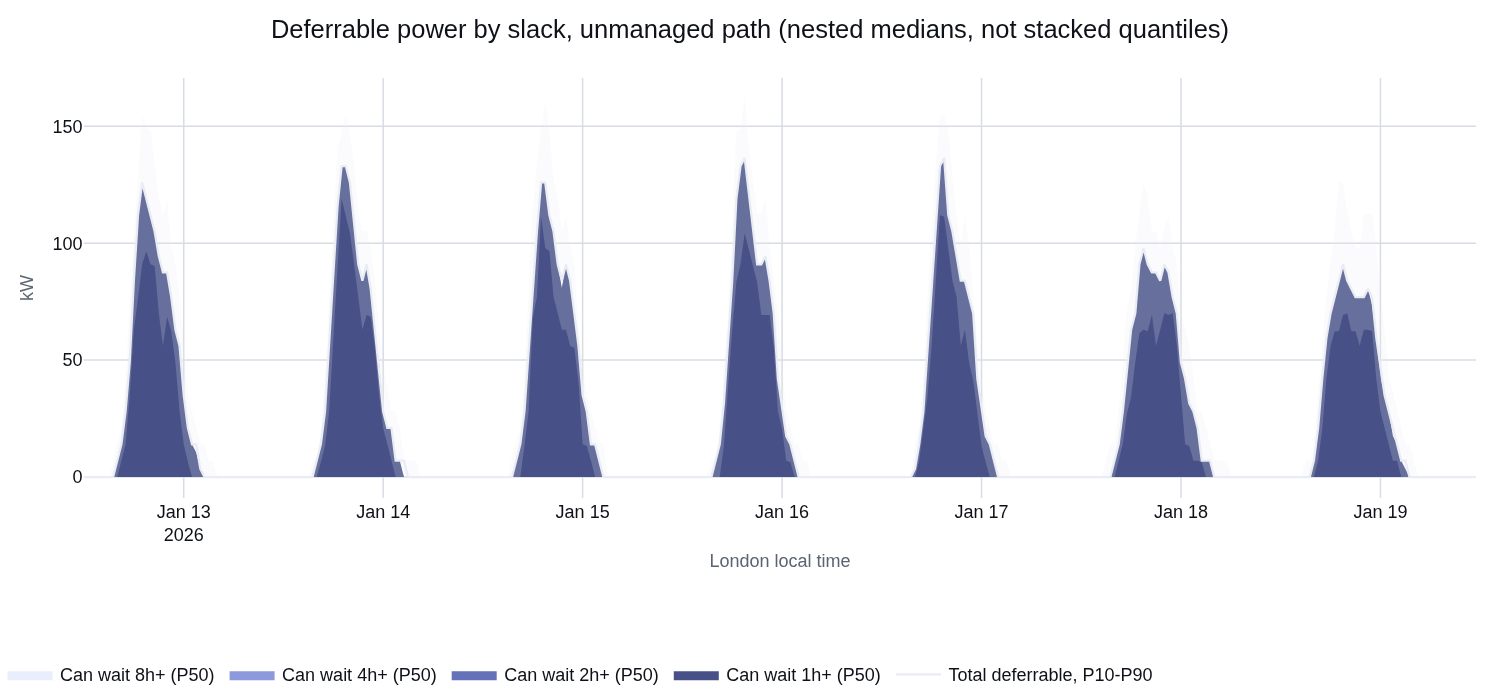

In [3]:
def _bucket_rows(bucket: str) -> pd.DataFrame:
    rows = base.deferrable_power_bands.query("slack_bucket == @bucket")
    return rows.sort_values("slot_index").reset_index(drop=True)


total = _bucket_rows("total")
x = total["interval_start_utc"].dt.tz_convert(LONDON)
cumulative_buckets = [f"at_least_{hours:g}h" for hours in AT_LEAST_HOURS]
# The same sequential scale the app's deferrable chart uses (ui/style.py SEQUENTIAL): it rises in
# lightness only, so "can wait longer" always reads as lighter, and it never touches teal (which
# means "the smart path did this" everywhere else).
stack_colours = [SEQUENTIAL[step][1] for step in (2, 3, 4, 5)]

deferrable_figure = go.Figure()
# Widest cumulative bucket first ("at least 8h"), so each narrower (less patient) nested area
# paints over it: legitimate because each is a subset of the one before it within every world (a
# nested-quantile fill), not a stack of independent quantiles summed together.
for bucket, colour in zip(reversed(cumulative_buckets), reversed(stack_colours), strict=True):
    rows = _bucket_rows(bucket)
    deferrable_figure.add_trace(
        go.Scatter(
            x=rows["interval_start_utc"].dt.tz_convert(LONDON),
            y=rows["p50"].round(1),
            mode="lines",
            line={"color": colour, "width": 0},
            fill="tozeroy",
            fillcolor=colour,
            name=f"Can wait {bucket.split('_')[-1]}+ (P50)",
        )
    )
band_and_line(
    deferrable_figure,
    x,
    total["p10"].round(1),
    total["p50"].round(1),
    total["p90"].round(1),
    name="Total deferrable, P10-P90",
    colour="#E9EDF3",
    width=1.5,
    band_alpha=0.2,
)
deferrable_figure.update_layout(
    title="Deferrable power by slack, unmanaged path (nested medians, not stacked quantiles)",
    xaxis_title="London local time",
    yaxis_title="kW",
)
apply_notebook_style(deferrable_figure, height=420)

In [4]:
example_times = ["18:00", "19:00", "22:00", "23:30"]
example = base.deferrable_power_bands.merge(night_slots, on="slot_index")
example = example[example["local_time_label"].isin(example_times)]
(
    example.pivot(index="slack_bucket", columns="local_time_label", values="p50")
    .reindex(list(DEFERRABLE_BUCKET_ORDER))
    .loc[:, example_times]
    .round(1)
    .rename_axis(index="Slack bucket (P50 kW)", columns="London time, night 0")
)

"London time, night 0",18:00,19:00,22:00,23:30
Slack bucket (P50 kW),,,,
under_1h,0.0,0.0,0.0,0.0
1_to_2h,0.0,0.0,0.0,0.0
2_to_4h,0.0,0.0,7.0,7.0
4_to_8h,21.0,56.0,70.0,35.0
8h_or_more,63.0,63.0,0.0,0.0
at_least_1h,84.0,126.0,87.5,56.0
at_least_2h,84.0,126.0,87.5,49.0
at_least_4h,84.0,126.0,77.0,35.0
at_least_8h,63.0,63.0,0.0,0.0


In [5]:
spread_labels = {"across_evs": "Across EVs", "across_weeks": "Across weeks"}
slack = base.flexibility_bands.query("metric == 'time_slack_hours'")
slack = slack.merge(night_slots, on="slot_index")
slack_table = slack[slack["local_time_label"] == "19:00"].assign(
    path=lambda frame: frame["path_id"].map(PATH_LABELS),
    spread=lambda frame: frame["spread"].map(spread_labels),
)
slack_table[["path", "spread", "world_count", "p10", "p50", "p90"]].round(2).rename(
    columns={"world_count": "simulated weeks with an EV below target"}
)

,path,spread,simulated weeks with an EV below target,p10,p50,p90
14,Unmanaged,Across EVs,20,5.50,8.22,9.60
62,Smart,Across EVs,20,5.36,8.10,9.15
110,Unmanaged,Across weeks,20,7.48,8.22,8.51
158,Smart,Across weeks,20,7.37,8.10,8.54


**Why the model never adds two quantiles together.** The five slack buckets are disjoint and sum
to the total inside every simulated week, but summing their *already-quantiled* P50 columns is a
different, wrong number: it adds five separate medians, each drawn from whichever weeks happened
to be high or low for that bucket, which is not the same set of weeks the true total's median
comes from (results contract v2 rule 3, "the UI never sums or averages quantiles").

In [6]:
bucket_ids = [bucket for bucket, _ in SLACK_BUCKETS]
pivot = base.deferrable_power_bands.pivot_table(
    index="slot_index", columns="slack_bucket", values="p50"
)
naive_sum = pivot[bucket_ids].sum(axis=1)
true_total = pivot["total"]
worst_slot = (naive_sum - true_total).abs().idxmax()
pd.DataFrame(
    {
        "quantity": [
            "Naive: sum of the five bucket P50s",
            "Correct: the total row's own P50 (world-first)",
            "Difference at the worst half-hour",
        ],
        "kW at the worst half-hour": [
            naive_sum.loc[worst_slot],
            true_total.loc[worst_slot],
            naive_sum.loc[worst_slot] - true_total.loc[worst_slot],
        ],
    }
).round(1)

,quantity,kW at the worst half-hour
0,Naive: sum of the five bucket P50s,73.5
1,Correct: the total row's own P50 (world-first),87.5
2,Difference at the worst half-hour,-14.0


In [7]:
# Read live from the six-cohort fixture (decision 0004 item 42), not from this run's own sample:
# at VEHICLE_COUNT = 50 the rarest cohort (always_plugged_in, a 1% population share) can draw zero
# EVs, so counting cohorts from `base.units` would silently undercount the model's own taxonomy.
cohort_fixture = assumptions.cohort_fixture(None)
flat_window_cohorts = sum(
    cohort.departure_local_hour == cohort.weekend_departure_local_hour
    for cohort in cohort_fixture.cohorts
)
total_cohorts = len(cohort_fixture.cohorts)
print(f"{flat_window_cohorts} of {total_cohorts} cohorts keep one flat window all week")

4 of 6 cohorts keep one flat window all week


Across EVs, one week's own plugged-in fleet at 19:00 already has a P10-P90 spread of slack hours
(some EVs nearly due to leave, some not for hours). Across weeks the typical EV's slack barely
moves instead, for a structural reason rather than a coincidence of this run: every simulated week
shares the same `study_slots` calendar (decision 0004 item 52), so night 0 is the same Monday in
every world, and each cohort's departure-clock mean and scale for that weekday are fixed constants
read from `model/assumptions.py`, not resampled per world. Only the per-EV, per-night random draw
around that fixed mean changes between worlds, which moves the *typical* EV's slack far less than
a weekday-versus-weekend swing would. A smaller, secondary reason most of the fleet moves even
less than that: the count above shows most cohorts keep one flat window all week (decision 0004
item 42), so their departure clock would not change even if night 0's weekday did. Both 19:00
numbers above are real and both are "the slack at 19:00" — they just answer different questions,
which is why the flexibility contract keeps them as two named spreads rather than one.

## 2. Each week's own peak: why the total is a band, not a number

`flexibility_weekly_summary` (contract v2 3.6e) measures the week's peak deferrable power the
same way `weekly_peak_summary` measures the charging peak (notebook 04, section 5): **each
simulated week's own peak first**, then the spread of those seven-night peaks across weeks. That
is a different number from the peak of the P50 band above, and it is always at least as large,
for a structural reason, not a coincidence of this run's random draws.

Call a week's own peak deferrable kW `Y_w` (the maximum over the week's half-hours) and the
band's per-slot median `Z_t` (the median over weeks at half-hour `t`). Because `Y_w` is the
largest value week `w` ever takes, every one of that week's half-hours satisfies value <= `Y_w`;
taking the median over weeks preserves that ordering, so `Z_t <= median_w(Y_w)` at every half-hour
`t`, including the half-hour where `Z_t` itself peaks. So the peak of the median can never exceed
the median of the weekly peaks. Smearing the model's real week-by-week peaks into one median
timeline (as the peak of the P50 band would) can only understate the peak the fleet actually
reaches in a typical week — the reason the contract insists on world-first aggregation here, not
a preference for bigger numbers.

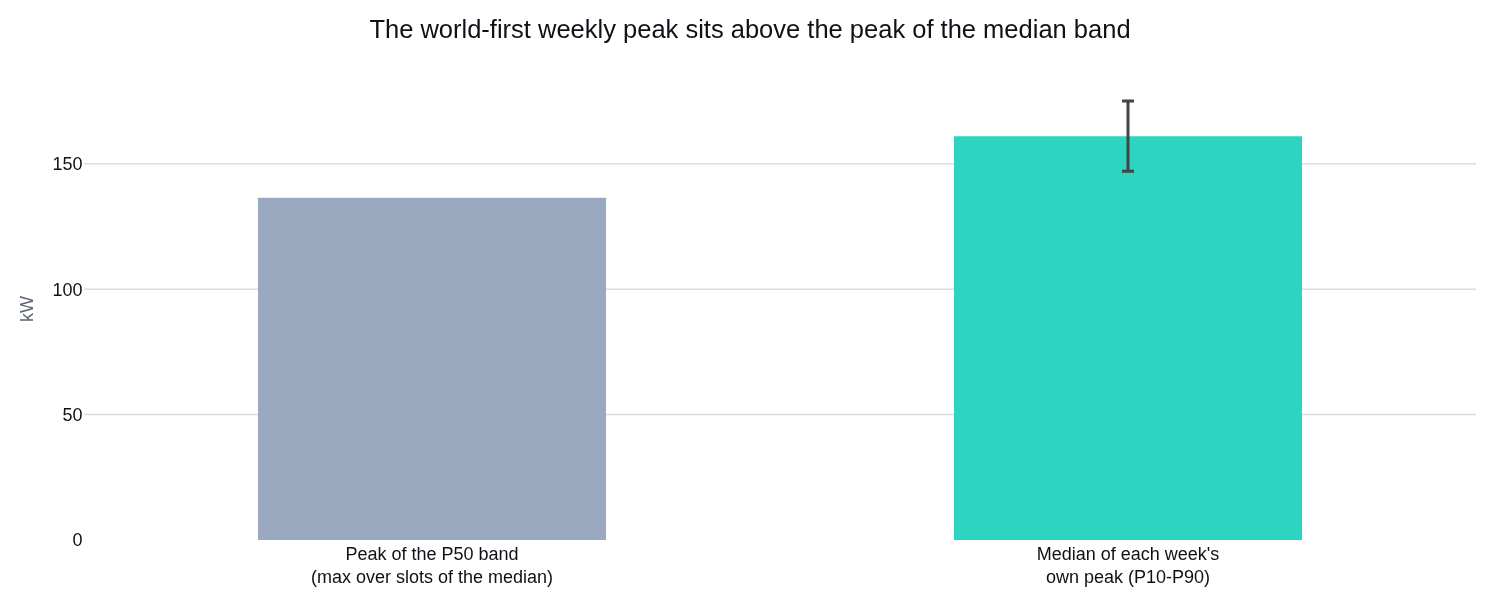

In [8]:
fws = base.flexibility_weekly_summary.iloc[0]
peak_of_median = float(total["p50"].max())
comparison_figure = go.Figure()
comparison_figure.add_trace(
    go.Bar(
        x=["Peak of the P50 band<br>(max over slots of the median)"],
        y=[peak_of_median],
        marker_color=PATH_STYLES["normal"]["color"],
        name="Peak of the P50 band",
        width=[0.5],
    )
)
comparison_figure.add_trace(
    go.Bar(
        x=["Median of each week's<br>own peak (P10-P90)"],
        y=[fws["peak_deferrable_kw_p50"]],
        error_y={
            "type": "data",
            "symmetric": False,
            "array": [fws["peak_deferrable_kw_p90"] - fws["peak_deferrable_kw_p50"]],
            "arrayminus": [fws["peak_deferrable_kw_p50"] - fws["peak_deferrable_kw_p10"]],
        },
        marker_color=PATH_STYLES["selected"]["color"],
        name="Median of each week's own peak",
        width=[0.5],
    )
)
comparison_figure.update_layout(
    title="The world-first weekly peak sits above the peak of the median band",
    yaxis_title="kW",
    showlegend=False,
)
apply_notebook_style(comparison_figure, height=360)

In [9]:
pd.DataFrame(
    [
        {"quantity": "Peak of the P50 band", "kW": peak_of_median},
        {"quantity": "Median of each week's own peak (P10)", "kW": fws["peak_deferrable_kw_p10"]},
        {"quantity": "Median of each week's own peak (P50)", "kW": fws["peak_deferrable_kw_p50"]},
        {"quantity": "Median of each week's own peak (P90)", "kW": fws["peak_deferrable_kw_p90"]},
        {
            "quantity": "Modal peak half-hour (London), and in how many of the simulated weeks",
            "kW": f"{pd.Timestamp(fws['peak_modal_interval_start_london']).strftime('%a %H:%M')}, "
            f"{int(fws['peak_modal_week_count'])} of {int(fws['world_count'])} weeks",
        },
    ]
).round(1)

,quantity,kW
0,Peak of the P50 band,136.5
1,Median of each week's own peak (P10),147.0
2,Median of each week's own peak (P50),161.0
3,Median of each week's own peak (P90),175.0
4,"Modal peak half-hour (London), and in how many...","Tue 19:30, 3 of 20 weeks"


## 3. Turn-up headroom on the smart path

`flexibility_bands` (contract v2 3.6c) reports `turn_up_headroom_kw` on both paths: the flexible
ceiling minus the path's own import in that half-hour, clipped at 0. On the unmanaged path this
is small most evenings, because an EV that can still charge usually is (it charges from plug-in).
On the smart path it is large at exactly the half-hours the smart charger is *waiting* for a
cheaper one later: the same ceiling, simply unused right then. That is why the app shows turn-up
headroom for the smart path only (decision 0004 item 54) — showing it for the unmanaged path too
would mostly repeat the deferrable-power chart above from the other side.

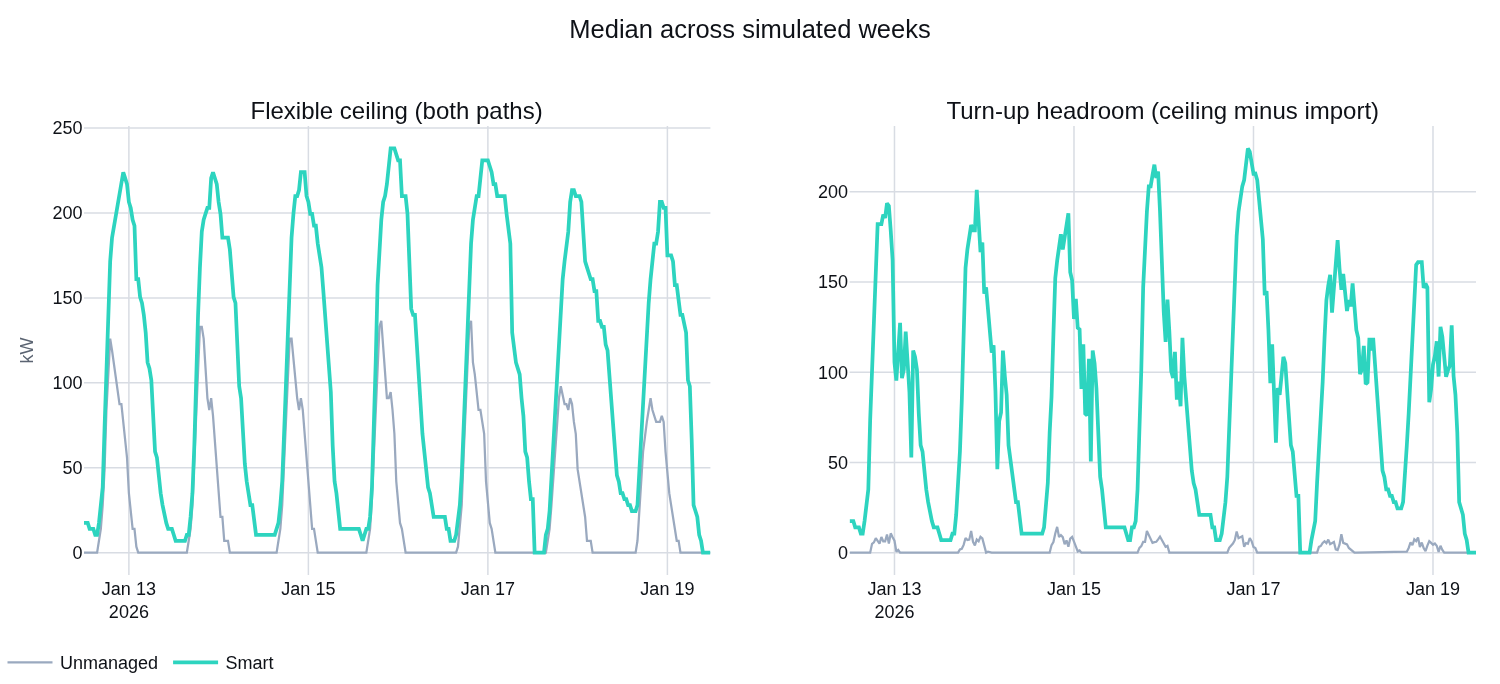

In [10]:
flexible_power = base.flexibility_bands.query("metric == 'flexible_power_kw'")
headroom = base.flexibility_bands.query("metric == 'turn_up_headroom_kw'")

headroom_figure = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=["Flexible ceiling (both paths)", "Turn-up headroom (ceiling minus import)"],
)
for path_id in ("normal", "selected"):
    style = PATH_STYLES[path_id]
    for col, frame in enumerate((flexible_power, headroom), start=1):
        rows = frame.query("path_id == @path_id").sort_values("slot_index")
        headroom_figure.add_trace(
            go.Scatter(
                x=rows["interval_start_utc"].dt.tz_convert(LONDON),
                y=rows["p50"].round(1),
                mode="lines",
                line={"color": style["color"], "width": style["width"]},
                name=PATH_LABELS[path_id],
                legendgroup=path_id,
                showlegend=col == 1,
            ),
            row=1,
            col=col,
        )
headroom_figure.update_yaxes(title_text="kW", col=1)
headroom_figure.update_layout(title="Median across simulated weeks")
apply_notebook_style(headroom_figure, height=380)

In [11]:
evening = base.study_slots.query("night_index == @EXAMPLE_NIGHT and local_time_label == '19:00'")
evening_slot = int(evening["slot_index"].iat[0])
at_evening = "path_id == @path_id and slot_index == @evening_slot"
summary_rows = []
for path_id in ("normal", "selected"):
    ceiling = flexible_power.query(at_evening)["p50"].iat[0]
    unused = headroom.query(at_evening)["p50"].iat[0]
    summary_rows.append(
        {
            "path": PATH_LABELS[path_id],
            "flexible ceiling, 19:00, night 0 (P50 kW)": ceiling,
            "turn-up headroom, 19:00, night 0 (P50 kW)": unused,
            "share of the ceiling unused": unused / ceiling if ceiling else float("nan"),
        }
    )
pd.DataFrame(summary_rows).round(3)

,path,"flexible ceiling, 19:00, night 0 (P50 kW)","turn-up headroom, 19:00, night 0 (P50 kW)",share of the ceiling unused
0,Unmanaged,126.0,8.048,0.064
1,Smart,171.5,164.500,0.959


## 4. A pointer to firm MW

Everything above is a same-week snapshot: kW right now. The firm-MW work (`model/availability.py`,
decision 0004 items 59, 60 and 64, trading contract v1 §10) asks a harder question: if Axle
promised a fixed MW for the next 0.5-4 hours, how much of that promise would actually turn up,
night after night, once real driving, non-response and charger-maker outages are in the mix? It
scores every EV three ways: **realised** (what it actually delivered that night), **potential**
(what it could have delivered had every session followed its plan and every maker been online)
and **plan-based** (what the aggregator could see and commit to at the night's 17:00 decision,
before that night's own uncertainty resolves). The gap between realised and plan-based is the
number a trader would call firm.

The module's kernel inputs have since landed: `ev_contributions`'s maker assignment, response
rate and outage draws per EV, and the planner's own plan book (`planned_home_import_kwh`,
`plan_status`), are part of the per-EV chunk pass any action-model `run_forecast` now runs, so
`base` above already carries `availability_bands`, `availability_world_slot` and
`firm_share_by_fleet_size`. This section still keeps to the module's own reporting constants and
its one function that needs nothing but a run's own study slots, to stay a short pointer rather
than repeat notebook 09, which reads those fleet-level frames from a full run directly (its
section 8, "Firm share against fleet size").

In [12]:
print("directions:", availability.DIRECTIONS)
print("hold durations (h):", availability.DURATION_HOURS)

decision_table = (
    pd.DataFrame({"17:00 decision slot": availability.decision_slots(base.study_slots, "17:00")})
    .rename_axis("night_index")
    .reset_index()
)
decision_table = decision_table.merge(
    base.study_slots[["slot_index", "interval_start_london"]],
    left_on="17:00 decision slot",
    right_on="slot_index",
).drop(columns="slot_index")
decision_table

directions: ('turn_down', 'turn_up')
hold durations (h): (0.5, 1.0, 2.0, 4.0)


,night_index,17:00 decision slot,interval_start_london
0,0,10,2026-01-12 17:00:00+00:00
1,1,58,2026-01-13 17:00:00+00:00
2,2,106,2026-01-14 17:00:00+00:00
3,3,154,2026-01-15 17:00:00+00:00
4,4,202,2026-01-16 17:00:00+00:00
5,5,250,2026-01-17 17:00:00+00:00
6,6,298,2026-01-18 17:00:00+00:00


## 5. Sanity checks

In [13]:
tolerance_kw = 1e-9
nested_ok = all(
    (
        _bucket_rows(f"at_least_{high:g}h")["p50"].to_numpy()
        <= _bucket_rows(f"at_least_{low:g}h")["p50"].to_numpy() + tolerance_kw
    ).all()
    for low, high in zip(AT_LEAST_HOURS, AT_LEAST_HOURS[1:])
)

flexible_power_normal = (
    flexible_power.query("path_id == 'normal'").sort_values("slot_index")["p50"].to_numpy()
)
deferrable_total = total["p50"].to_numpy()

checks = {
    "summing the five bucket P50s visibly disagrees with the total's own P50": (
        (naive_sum - true_total).abs().max() > 1.0
    ),
    "nested 'at least N h' medians never cross (a subset's median can't exceed its superset's)": (
        nested_ok
    ),
    "flexible_power_kw (normal path) equals the deferrable total exactly": bool(
        np.allclose(flexible_power_normal, deferrable_total)
    ),
    "the peak of the median band is no larger than the median of each week's own peak": (
        peak_of_median <= float(fws["peak_deferrable_kw_p50"]) + tolerance_kw
    ),
    "turn-up headroom is never negative on either path": bool(
        (headroom[["p10", "p50", "p90"]] >= -tolerance_kw).all().all()
    ),
    "turn-up headroom's median is larger on the smart path, most evenings": (
        (
            headroom.query("path_id == 'selected'").sort_values("slot_index")["p50"].to_numpy()
            > headroom.query("path_id == 'normal'").sort_values("slot_index")["p50"].to_numpy()
        ).mean()
        > 0.5
    ),
    "the 17:00 decision slot exists for every session night, in order": bool(
        (np.diff(availability.decision_slots(base.study_slots, "17:00")) > 0).all()
    )
    and len(availability.decision_slots(base.study_slots, "17:00")) == 7,
}
for description, passed in checks.items():
    assert passed, description
pd.DataFrame({"check": checks.keys(), "passed": checks.values()})

,check,passed
0,summing the five bucket P50s visibly disagrees...,True
1,nested 'at least N h' medians never cross (a s...,True
2,flexible_power_kw (normal path) equals the def...,True
3,the peak of the median band is no larger than ...,True
4,turn-up headroom is never negative on either path,True
5,turn-up headroom's median is larger on the sma...,True
6,the 17:00 decision slot exists for every sessi...,True


## 6. Limitations

- The run here is small (50 EVs, 20 simulated weeks) for speed; its bands are wider and its
  percentiles rougher than the app's default run.
- Everything above uses one home charging power and one departure margin for every EV (decision
  0004 items 34 and 51); a real fleet's flexible power would also vary by charger and driver.
- Deferrable power counts only whole half-hours of remaining need (`ceil`, because the kernel
  dispatches in whole slots), so an EV a few minutes over a slack boundary shows as needing the
  full extra half-hour.
- The firm-MW pointer above is deliberately shallow, now by choice rather than by a missing
  kernel wire: `run_forecast`'s fleet-level firm-MW frames (deliverable MW bands,
  `firm_share_by_fleet_size`, the calibration backtest) are live, and notebook 09 is their own
  notebook (its sections 5-9). A newsvendor-style rule for how much firm MW to *promise* (as
  opposed to `trading.commitment_rule = "newsvendor"`, the day-ahead trading position notebook 06
  covers, which is a different setting) is still open work: today's product sheet promises the
  across-weeks P10, a fixed convention, not an optimised trade-off against an under-delivery cost.